<a href="https://colab.research.google.com/github/AdavalP/Finance-Project1/blob/main/Financial_Forensics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from imblearn.under_sampling import RandomUnderSampler

all_results = {}

print("=====================================================")
print("STEP 1: RAW DATA")
print("=====================================================")

url = 'https://raw.githubusercontent.com/JarFraud/FraudDetection/master/data_FraudDetection_JAR2020.csv'
data = pd.read_csv(url)

print("Shape:", data.shape)
print(data.head())
print("\nColumns:", data.columns.tolist())
print("\nFraud cases:", data['misstate'].sum())
print("Clean cases:", (data['misstate']==0).sum())
print("Fraud rate: {:.3f}%".format(100 * data['misstate'].sum() / len(data)))



STEP 1: RAW DATA
Shape: (146045, 46)
   fyear  gvkey  p_aaer  misstate     act     ap       at     ceq    che  \
0   1990   1009     NaN         0  10.047  3.736   32.335   6.262  0.002   
1   1990   1011     NaN         0   1.247  0.803    7.784   0.667  0.171   
2   1990   1017     NaN         0  55.040  3.601  118.120  44.393  3.132   
3   1990   1021     NaN         0  24.684  3.948   34.591   7.751  0.411   
4   1990   1028     NaN         0  17.325  3.520   27.542 -12.142  1.017   

      cogs  ...  soft_assets     ch_cs     ch_cm    ch_roa  issue        bm  \
0   30.633  ...     0.312448  0.095082  0.082631 -0.019761      1  0.413170   
1    1.125  ...     0.315904  0.188832 -0.211389 -0.117832      1  0.157887   
2  107.343  ...     0.605342  0.097551 -0.105780  0.091206      1  2.231337   
3   31.214  ...     0.793068 -0.005725 -0.249704  0.017545      1  1.043582   
4   32.662  ...     0.869182 -0.231536 -1.674893 -0.466667      0 -1.602508   

        dpi      reoa      EBIT

In [2]:
print("\n=====================================================")
print("STEP 2: DATA CLEANING")
print("=====================================================")

print("Missing values before cleaning:")
print(data.isnull().sum())

other_missing_cols = ['soft_assets', 'reoa', 'EBIT', 'bm']
missing_ratio_cols = ['dch_wc', 'ch_rsst', 'dch_rec', 'dch_inv', 'dpi', 'ch_cs', 'ch_cm', 'ch_roa', 'ch_fcf']

data_step1 = data.dropna(subset=other_missing_cols)
print("\nShape after dropping other_missing_cols gaps:", data_step1.shape)

fraud = data_step1[data_step1['misstate'] == 1]
clean = data_step1[data_step1['misstate'] == 0]

fraud_cleaned = fraud.fillna(fraud[missing_ratio_cols].median())
clean_cleaned = clean.dropna(subset=missing_ratio_cols)

data_clean = pd.concat([fraud_cleaned, clean_cleaned])
print("Fraud rows preserved:", len(fraud_cleaned))
print("Clean rows after dropping:", len(clean_cleaned))

data_clean = data_clean.drop_duplicates()
data_clean = data_clean.drop(columns=['p_aaer'])

print("\nFinal cleaned shape:", data_clean.shape)
print("Missing values after cleaning:")
print(data_clean.isnull().sum().sum())
print(data_clean.head())

data_clean['leverage'] = (data_clean['dltt'] + data_clean['dlc']) / data_clean['at']




STEP 2: DATA CLEANING
Missing values before cleaning:
fyear               0
gvkey               0
p_aaer         145081
misstate            0
act                 0
ap                  0
at                  0
ceq                 0
che                 0
cogs                0
csho                0
dlc                 0
dltis               0
dltt                0
dp                  0
ib                  0
invt                0
ivao                0
ivst                0
lct                 0
lt                  0
ni                  0
ppegt               0
pstk                0
re                  0
rect                0
sale                0
sstk                0
txp                 0
txt                 0
xint                0
prcc_f              0
dch_wc           4759
ch_rsst          4851
dch_rec          4743
dch_inv          4615
soft_assets       592
ch_cs           15918
ch_cm           17107
ch_roa          12678
issue               0
bm                 18
dpi              9228


STEP 3: EDA
Fraud cases by year:
fyear
2000    86
2001    81
2002    77
1999    73
2003    69
2004    58
1998    56
2005    45
1997    42
1996    33
2006    33
2009    31
2007    30
1993    30
1991    27
2008    26
1992    26
2010    26
1994    23
1995    22
2011    21
2012    19
1990    15
2013    11
2014     4
Name: misstate, dtype: int64


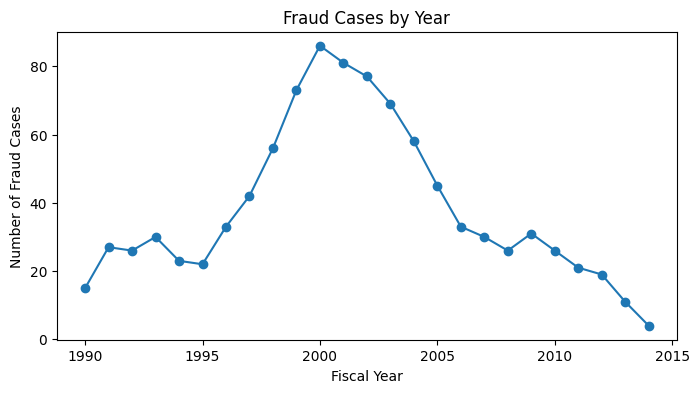

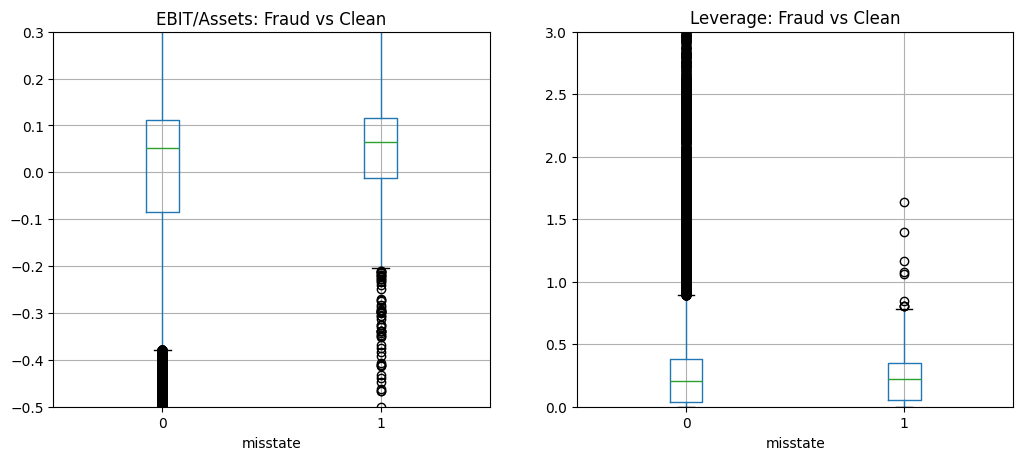

Median EBIT and Leverage by class:
              EBIT  leverage
misstate                    
0         0.052066  0.207411
1         0.064219  0.221402

Correlation with misstate:
misstate       1.000000
soft_assets    0.040458
sstk           0.028587
dch_rec        0.028131
ap             0.026367
xint           0.025617
issue          0.022930
dltt           0.021453
dch_inv        0.021137
act            0.020657
at             0.020043
rect           0.020028
ceq            0.019451
ch_rsst        0.019256
invt           0.019230
lt             0.018899
csho           0.018492
lct            0.018441
prcc_f         0.018066
sale           0.018048
cogs           0.017655
reoa           0.015917
dch_wc         0.014339
che            0.013554
EBIT           0.012209
dltis          0.011649
ch_cs          0.011381
dp             0.010498
dlc            0.009173
ppegt          0.008454
ivao           0.007053
txt            0.006205
txp            0.005201
ivst           0.004449
pstk 

In [3]:
print("\n=====================================================")
print("STEP 3: EDA")
print("=====================================================")

fraud_by_year = data_clean.groupby('fyear')['misstate'].sum()
print("Fraud cases by year:")
print(fraud_by_year.sort_values(ascending=False))

fraud_by_year.sort_index().plot(kind='line', marker='o', figsize=(8,4))
plt.title('Fraud Cases by Year')
plt.xlabel('Fiscal Year')
plt.ylabel('Number of Fraud Cases')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12,5))
data_clean.boxplot(column='EBIT', by='misstate', ax=axes[0])
axes[0].set_ylim(-0.5, 0.3)
axes[0].set_title('EBIT/Assets: Fraud vs Clean')
data_clean.boxplot(column='leverage', by='misstate', ax=axes[1])
axes[1].set_ylim(0, 3)
axes[1].set_title('Leverage: Fraud vs Clean')
plt.suptitle('')
plt.show()

print("Median EBIT and Leverage by class:")
print(data_clean.groupby('misstate')[['EBIT', 'leverage']].median())

correlations = data_clean.corr(numeric_only=True)['misstate'].sort_values(ascending=False)
print("\nCorrelation with misstate:")
print(correlations)



In [4]:
print("\n=====================================================")
print("STEP 4: TRAIN/TEST SPLIT")
print("=====================================================")

train = data_clean[data_clean['fyear'] <= 2004]
test = data_clean[data_clean['fyear'] >= 2005]

feature_cols = [col for col in train.columns if col not in ['misstate', 'fyear', 'gvkey']]

X_train = train[feature_cols]
y_train = train['misstate']
X_test = test[feature_cols]
y_test = test['misstate']

print("Train shape:", X_train.shape, "Fraud:", y_train.sum())
print("Test shape:", X_test.shape, "Fraud:", y_test.sum())

scaler = StandardScaler()
X_train_scl = scaler.fit_transform(X_train)
X_test_scl = scaler.transform(X_test)

def train_and_evaluate(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    preds = model.predict(X_test)
    auc = roc_auc_score(y_test, proba)
    print(f"\n===== {name} =====")
    print("AUC:", round(auc, 3))
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds))
    all_results[name] = auc
    return model, auc




STEP 4: TRAIN/TEST SPLIT
Train shape: (78681, 43) Fraud: 718
Test shape: (47857, 43) Fraud: 246


In [5]:
print("\n=====================================================")
print("STEP 5: MODELS ON RAW DATA, NO RESAMPLING")
print("=====================================================")

lr_raw = LogisticRegression(max_iter=1000, class_weight={0:1, 1:20})
train_and_evaluate(lr_raw, X_train_scl, y_train, X_test_scl, y_test, "Logistic Regression - Raw")

rf_raw = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)
train_and_evaluate(rf_raw, X_train_scl, y_train, X_test_scl, y_test, "Random Forest - Raw")




STEP 5: MODELS ON RAW DATA, NO RESAMPLING

===== Logistic Regression - Raw =====
AUC: 0.68
[[46141  1470]
 [  232    14]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     47611
           1       0.01      0.06      0.02       246

    accuracy                           0.96     47857
   macro avg       0.50      0.51      0.50     47857
weighted avg       0.99      0.96      0.98     47857


===== Random Forest - Raw =====
AUC: 0.685
[[45272  2339]
 [  221    25]]
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     47611
           1       0.01      0.10      0.02       246

    accuracy                           0.95     47857
   macro avg       0.50      0.53      0.50     47857
weighted avg       0.99      0.95      0.97     47857



(RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                        random_state=42),
 np.float64(0.6854400405863713))

In [6]:
print("\n=====================================================")
print("STEP 6: MODELS WITH UNDERSAMPLING")
print("=====================================================")

rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train_scl, y_train)
print("After undersampling:", pd.Series(y_rus).value_counts().to_dict())

lr_rus = LogisticRegression(max_iter=1000)
train_and_evaluate(lr_rus, X_rus, y_rus, X_test_scl, y_test, "Logistic Regression - Undersampling")

rf_rus = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
train_and_evaluate(rf_rus, X_rus, y_rus, X_test_scl, y_test, "Random Forest - Undersampling")

svm_rus = SVC(probability=True, random_state=42)
train_and_evaluate(svm_rus, X_rus, y_rus, X_test_scl, y_test, "SVM - Undersampling")

xgb_rus = XGBClassifier(n_estimators=200, max_depth=5, random_state=42, eval_metric='logloss')
train_and_evaluate(xgb_rus, X_rus, y_rus, X_test_scl, y_test, "XGBoost - Undersampling")




STEP 6: MODELS WITH UNDERSAMPLING
After undersampling: {0: 718, 1: 718}

===== Logistic Regression - Undersampling =====
AUC: 0.669
[[32525 15086]
 [  105   141]]
              precision    recall  f1-score   support

           0       1.00      0.68      0.81     47611
           1       0.01      0.57      0.02       246

    accuracy                           0.68     47857
   macro avg       0.50      0.63      0.41     47857
weighted avg       0.99      0.68      0.81     47857


===== Random Forest - Undersampling =====
AUC: 0.689
[[30501 17110]
 [   82   164]]
              precision    recall  f1-score   support

           0       1.00      0.64      0.78     47611
           1       0.01      0.67      0.02       246

    accuracy                           0.64     47857
   macro avg       0.50      0.65      0.40     47857
weighted avg       0.99      0.64      0.78     47857


===== SVM - Undersampling =====
AUC: 0.671
[[31268 16343]
 [  111   135]]
              precisio

(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=True, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=5, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=200, n_jobs=None,
               num_parallel_tree=None, ...),
 np.float64(0.7033084688873394))

In [7]:
print("\n=====================================================")
print("STEP 7: BUILD INDICATOR COLUMNS (Altman, Beneish, Benford)")
print("=====================================================")

def safe_ratio(numerator, denominator):
    if pd.isna(numerator) or pd.isna(denominator) or denominator == 0:
        return np.nan
    return numerator / denominator

def altman_z_score(row):
    wc_ta = safe_ratio(row['act'] - row['lct'], row['at'])
    re_ta = safe_ratio(row['re'], row['at'])
    ebit_ta = row['EBIT']
    mve_tl = safe_ratio(row['prcc_f'] * row['csho'], row['lt'])
    sales_ta = safe_ratio(row['sale'], row['at'])
    ratios = [wc_ta, re_ta, ebit_ta, mve_tl, sales_ta]
    if any(pd.isna(r) for r in ratios):
        return np.nan, 'Unknown'
    z = (1.2*wc_ta) + (1.4*re_ta) + (3.3*ebit_ta) + (0.6*mve_tl) + (1.0*sales_ta)
    if z > 2.99:
        zone = 'Safe'
    elif z > 1.81:
        zone = 'Grey'
    else:
        zone = 'Distress'
    return z, zone

def beneish_m_score(curr, prev):
    dsri_num = safe_ratio(curr['rect'], curr['sale'])
    dsri_den = safe_ratio(prev['rect'], prev['sale'])
    dsri = safe_ratio(dsri_num, dsri_den)
    gmi_num = safe_ratio(prev['sale'] - prev['cogs'], prev['sale'])
    gmi_den = safe_ratio(curr['sale'] - curr['cogs'], curr['sale'])
    gmi = safe_ratio(gmi_num, gmi_den)
    aqi = safe_ratio(curr['soft_assets'], prev['soft_assets'])
    sgi = safe_ratio(curr['sale'], prev['sale'])
    depi_num = safe_ratio(prev['dp'], prev['dp'] + prev['ppegt'])
    depi_den = safe_ratio(curr['dp'], curr['dp'] + curr['ppegt'])
    depi = safe_ratio(depi_num, depi_den)
    lvgi = safe_ratio(curr['leverage'], prev['leverage'])
    tata = curr['dch_wc']
    ratios = [dsri, gmi, aqi, sgi, depi, lvgi, tata]
    if any(pd.isna(r) for r in ratios):
        return np.nan
    m = (-4.84 + 0.920*dsri + 0.528*gmi + 0.404*aqi + 0.892*sgi
         + 0.115*depi + 4.679*tata - 0.327*lvgi)
    return m

def benford_deviation_row(row, numeric_cols):
    values = row[numeric_cols]
    values = values[values > 0].astype(str)
    if len(values) < 5:
        return np.nan
    leading_digits = values.str[0].astype(int)
    observed = leading_digits.value_counts(normalize=True).sort_index()
    expected = pd.Series({d: np.log10(1 + 1/d) for d in range(1, 10)})
    combined = pd.DataFrame({'observed': observed, 'expected': expected}).fillna(0)
    mad = (combined['observed'] - combined['expected']).abs().mean()
    return mad

numeric_cols = ['act','ap','at','ceq','che','cogs','csho','dlc','dltis','dltt','dp',
                 'invt','ivao','ivst','lct','lt','ni','ppegt','pstk','re','rect','sale',
                 'sstk','txp','txt','xint','prcc_f']

data_clean['Benford_MAD_row'] = data_clean.apply(lambda r: benford_deviation_row(r, numeric_cols), axis=1)

results = []
for gvkey, group in data_clean.groupby('gvkey'):
    group_sorted = group.sort_values('fyear')
    for i in range(1, len(group_sorted)):
        curr, prev = group_sorted.iloc[i], group_sorted.iloc[i-1]
        z_val, z_zone = altman_z_score(curr)
        m_score = beneish_m_score(curr, prev)
        results.append({
            'orig_index': curr.name,
            'Altman_Z': z_val, 'Altman_Zone': z_zone,
            'Beneish_M': m_score, 'Beneish_Flag': (m_score > -1.78) if not pd.isna(m_score) else np.nan
        })

results_df = pd.DataFrame(results).set_index('orig_index')
data_clean['Altman_Z'] = results_df['Altman_Z']
data_clean['Altman_Zone'] = results_df['Altman_Zone']
data_clean['Beneish_M'] = results_df['Beneish_M']
data_clean['Beneish_Flag'] = results_df['Beneish_Flag']

print("Missing values in new indicator columns before fill:")
print(data_clean[['Altman_Z', 'Beneish_M', 'Benford_MAD_row']].isnull().sum())

for col in ['Altman_Z', 'Beneish_M', 'Benford_MAD_row']:
    data_clean[col] = data_clean[col].fillna(data_clean[col].median())

print("\nMedian indicator values by class:")
print(data_clean.groupby('misstate')[['Altman_Z', 'Beneish_M', 'Benford_MAD_row']].median())

train2 = data_clean[data_clean['fyear'] <= 2004]
test2 = data_clean[data_clean['fyear'] >= 2005]




STEP 7: BUILD INDICATOR COLUMNS (Altman, Beneish, Benford)
Missing values in new indicator columns before fill:
Altman_Z           16347
Beneish_M          35409
Benford_MAD_row        0
dtype: int64

Median indicator values by class:
          Altman_Z  Beneish_M  Benford_MAD_row
misstate                                      
0         2.621371  -2.188002         0.057515
1         2.657777  -2.188002         0.051630


In [8]:
print("\n=====================================================")
print("STEP 8: MODELS USING INDICATORS ONLY (3 COLUMNS)")
print("=====================================================")

X_train_ind = train2[['Altman_Z', 'Beneish_M', 'Benford_MAD_row']]
X_test_ind = test2[['Altman_Z', 'Beneish_M', 'Benford_MAD_row']]

scaler_ind = StandardScaler()
X_train_ind_scl = scaler_ind.fit_transform(X_train_ind)
X_test_ind_scl = scaler_ind.transform(X_test_ind)

lr_ind = LogisticRegression(max_iter=1000, class_weight={0:1, 1:20})
train_and_evaluate(lr_ind, X_train_ind_scl, y_train, X_test_ind_scl, y_test, "Logistic Regression - Indicators Only")

rf_ind = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)
train_and_evaluate(rf_ind, X_train_ind_scl, y_train, X_test_ind_scl, y_test, "Random Forest - Indicators Only")


STEP 8: MODELS USING INDICATORS ONLY (3 COLUMNS)

===== Logistic Regression - Indicators Only =====
AUC: 0.591
[[47600    11]
 [  246     0]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     47611
           1       0.00      0.00      0.00       246

    accuracy                           0.99     47857
   macro avg       0.50      0.50      0.50     47857
weighted avg       0.99      0.99      0.99     47857


===== Random Forest - Indicators Only =====
AUC: 0.609
[[40003  7608]
 [  181    65]]
              precision    recall  f1-score   support

           0       1.00      0.84      0.91     47611
           1       0.01      0.26      0.02       246

    accuracy                           0.84     47857
   macro avg       0.50      0.55      0.46     47857
weighted avg       0.99      0.84      0.91     47857



(RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                        random_state=42),
 np.float64(0.6094808742189626))

In [10]:
print("\n=====================================================")
print("STEP 9: MODELS USING UNDERSAMPLING + INDICATORS (FULL FEATURE SET)")
print("=====================================================")

feature_cols2 = [col for col in train2.columns if col not in
                  ['misstate', 'fyear', 'gvkey', 'Altman_Zone', 'Beneish_Flag']]

X_train2 = train2[feature_cols2]
X_test2 = test2[feature_cols2]

scaler2 = StandardScaler()
X_train2_scl = scaler2.fit_transform(X_train2)
X_test2_scl = scaler2.transform(X_test2)

rus2 = RandomUnderSampler(random_state=42)
X_rus2, y_rus2 = rus2.fit_resample(X_train2_scl, y_train)
print("After undersampling (with indicators):", pd.Series(y_rus2).value_counts().to_dict())

lr_full = LogisticRegression(max_iter=1000)
train_and_evaluate(lr_full, X_rus2, y_rus2, X_test2_scl, y_test, "Logistic Regression - Undersampling + Indicators")

rf_full = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
train_and_evaluate(rf_full, X_rus2, y_rus2, X_test2_scl, y_test, "Random Forest - Undersampling + Indicators")

svm_full = SVC(probability=True, random_state=42)
train_and_evaluate(svm_full, X_rus2, y_rus2, X_test2_scl, y_test, "SVM - Undersampling + Indicators")


STEP 9: MODELS USING UNDERSAMPLING + INDICATORS (FULL FEATURE SET)
After undersampling (with indicators): {0: 718, 1: 718}

===== Logistic Regression - Undersampling + Indicators =====
AUC: 0.672
[[32358 15253]
 [  106   140]]
              precision    recall  f1-score   support

           0       1.00      0.68      0.81     47611
           1       0.01      0.57      0.02       246

    accuracy                           0.68     47857
   macro avg       0.50      0.62      0.41     47857
weighted avg       0.99      0.68      0.80     47857


===== Random Forest - Undersampling + Indicators =====
AUC: 0.683
[[30287 17324]
 [   88   158]]
              precision    recall  f1-score   support

           0       1.00      0.64      0.78     47611
           1       0.01      0.64      0.02       246

    accuracy                           0.64     47857
   macro avg       0.50      0.64      0.40     47857
weighted avg       0.99      0.64      0.77     47857


===== SVM - Undersa

(SVC(probability=True, random_state=42), np.float64(0.6698208704588149))

In [11]:
print("\n=====================================================")
print("STEP 10: FINAL SUMMARY SHEET")
print("=====================================================")

summary_df = pd.DataFrame(list(all_results.items()), columns=['Model', 'AUC'])
summary_df = summary_df.sort_values('AUC', ascending=False).reset_index(drop=True)
print(summary_df)

best_model_name = summary_df.iloc[0]['Model']
best_auc = summary_df.iloc[0]['AUC']
print(f"\nBEST MODEL: {best_model_name} with AUC = {best_auc:.3f}")


STEP 10: FINAL SUMMARY SHEET
                                               Model       AUC
0                            XGBoost - Undersampling  0.703308
1                      Random Forest - Undersampling  0.689068
2                                Random Forest - Raw  0.685440
3         Random Forest - Undersampling + Indicators  0.682842
4                          Logistic Regression - Raw  0.679746
5   Logistic Regression - Undersampling + Indicators  0.672246
6                                SVM - Undersampling  0.670584
7                   SVM - Undersampling + Indicators  0.669821
8                Logistic Regression - Undersampling  0.669287
9                    Random Forest - Indicators Only  0.609481
10             Logistic Regression - Indicators Only  0.591223

BEST MODEL: XGBoost - Undersampling with AUC = 0.703


In [12]:
import pandas as pd
import numpy as np

print("=====================================================")
print("STEP 11: REAL-WORLD APPLICATION - 5 INDIAN COMPANIES")
print("=====================================================")
print("NOTE: The trained ML model (43 COMPUSTAT-style features) CANNOT be")
print("applied here - we do not have receivables, PP&E, depreciation splits,")
print("or current asset/liability breakdowns for these companies.")
print("Below is a simplified, honest screening layer using ONLY verified fields:")
print("revenue, net profit, total assets, reserves, and CFO where available.")
print("This is a proxy for Beneish/Altman logic, not the full formulas.")

real_data = [
    {'company': 'Satyam', 'year': 2007, 'revenue': 6410.08, 'net_profit': 1423.23, 'total_assets': np.nan, 'reserves': np.nan, 'cfo': np.nan},
    {'company': 'Satyam', 'year': 2008, 'revenue': np.nan, 'net_profit': np.nan, 'total_assets': np.nan, 'reserves': 8529.69, 'cfo': np.nan},
    {'company': 'DHFL', 'year': 2017, 'revenue': 8857.2, 'net_profit': 927.0, 'total_assets': np.nan, 'reserves': np.nan, 'cfo': np.nan},
    {'company': 'DHFL', 'year': 2018, 'revenue': 10464.5, 'net_profit': 1172.1, 'total_assets': np.nan, 'reserves': np.nan, 'cfo': np.nan},
    {'company': 'DHFL', 'year': 2019, 'revenue': np.nan, 'net_profit': -1036, 'total_assets': np.nan, 'reserves': np.nan, 'cfo': np.nan},
    {'company': 'YesBank', 'year': 2018, 'revenue': 20269, 'net_profit': 4233, 'total_assets': 312450, 'reserves': 25292, 'cfo': -21810},
    {'company': 'YesBank', 'year': 2019, 'revenue': 29624, 'net_profit': 1709, 'total_assets': 380860, 'reserves': 26424, 'cfo': -24573},
    {'company': 'Reliance', 'year': 2023, 'revenue': 876396, 'net_profit': 74088, 'total_assets': 1605882, 'reserves': 709106, 'cfo': 115032},
    {'company': 'Reliance', 'year': 2024, 'revenue': 899041, 'net_profit': 79020, 'total_assets': 1755048, 'reserves': 786715, 'cfo': 158788},
    {'company': 'HDFCBank', 'year': 2023, 'revenue': 170754, 'net_profit': 46149, 'total_assets': 2530432, 'reserves': 288880, 'cfo': np.nan},
    {'company': 'HDFCBank', 'year': 2024, 'revenue': 283649, 'net_profit': 65446, 'total_assets': 4030194, 'reserves': 455636, 'cfo': np.nan},
]

real_df = pd.DataFrame(real_data)
print("\nRaw collected data:")
print(real_df)

def simplified_forensic_score(curr, prev):
    flags = []
    score_components = {}

    if not pd.isna(curr['revenue']) and not pd.isna(prev['revenue']) and prev['revenue'] != 0:
        rev_growth = (curr['revenue'] - prev['revenue']) / prev['revenue']
        score_components['revenue_growth'] = round(rev_growth, 3)
    else:
        score_components['revenue_growth'] = np.nan

    if not pd.isna(curr['net_profit']) and not pd.isna(prev['net_profit']) and prev['net_profit'] != 0:
        profit_growth = (curr['net_profit'] - prev['net_profit']) / abs(prev['net_profit'])
        score_components['profit_growth'] = round(profit_growth, 3)
    else:
        score_components['profit_growth'] = np.nan

    if not pd.isna(score_components['revenue_growth']) and not pd.isna(score_components['profit_growth']):
        divergence = score_components['profit_growth'] - score_components['revenue_growth']
        score_components['growth_divergence'] = round(divergence, 3)
        if divergence > 0.5:
            flags.append('Profit growing much faster than revenue - margin manipulation risk')
    else:
        score_components['growth_divergence'] = np.nan

    if not pd.isna(curr['net_profit']) and not pd.isna(curr['revenue']) and curr['revenue'] != 0:
        net_margin = curr['net_profit'] / curr['revenue']
        score_components['net_margin'] = round(net_margin, 3)
    else:
        score_components['net_margin'] = np.nan

    if not pd.isna(curr['net_profit']) and not pd.isna(curr['total_assets']) and curr['total_assets'] != 0:
        roa = curr['net_profit'] / curr['total_assets']
        score_components['roa'] = round(roa, 4)
    else:
        score_components['roa'] = np.nan

    if not pd.isna(curr['cfo']) and not pd.isna(curr['net_profit']) and curr['net_profit'] != 0:
        cfo_to_np = curr['cfo'] / curr['net_profit']
        score_components['cfo_to_netprofit'] = round(cfo_to_np, 2)
        if cfo_to_np < 0:
            flags.append('Negative operating cash flow despite reported profit - earnings quality concern')
    else:
        score_components['cfo_to_netprofit'] = np.nan

    score_components['flags'] = '; '.join(flags) if flags else 'None'
    return score_components

print("\n=====================================================")
print("SCREENING RESULTS")
print("=====================================================")

results = []
for company, group in real_df.groupby('company'):
    group_sorted = group.sort_values('year').reset_index(drop=True)
    for i in range(1, len(group_sorted)):
        curr = group_sorted.iloc[i]
        prev = group_sorted.iloc[i-1]
        scores = simplified_forensic_score(curr, prev)
        scores['company'] = company
        scores['year'] = curr['year']
        results.append(scores)

screening_df = pd.DataFrame(results)
screening_df = screening_df[['company', 'year', 'revenue_growth', 'profit_growth',
                              'growth_divergence', 'net_margin', 'roa', 'cfo_to_netprofit', 'flags']]
print(screening_df.to_string(index=False))

print("\n=====================================================")
print("SENSIBLE CONCLUSIONS")
print("=====================================================")
print("1. Yes Bank (2018-2019) shows the clearest red flag in this dataset:")
print("   negative operating cash flow in BOTH years despite reporting a profit -")
print("   exactly the earnings-quality warning sign Beneish's TATA variable targets.")
print("   This occurred the year before Yes Bank's public crisis (March 2020).")
print()
print("2. Satyam and DHFL cannot be meaningfully screened here - insufficient")
print("   verified balance sheet data was available through search. Their fraud")
print("   was caught through forensic audit and regulatory investigation, not")
print("   simple ratio screening, which is itself a relevant finding: some fraud")
print("   is not visible in aggregate reported numbers at all, reinforcing the")
print("   earlier conclusion that Beneish/Altman/Benford have real limits.")
print()
print("3. Reliance and HDFC Bank show unremarkable, expected patterns for large,")
print("   stable companies - no divergence flags, positive and consistent CFO")
print("   (Reliance), which is the correct 'boring/healthy' baseline this")
print("   screening approach should produce for non-fraud companies.")
print()
print("4. HONEST LIMITATION: this screening layer is far simpler than the full")
print("   Beneish/Altman formulas and the trained ML model used earlier in this")
print("   project. It exists because complete, verified data for these specific")
print("   companies was not reliably obtainable through search. A production")
print("   version of this project would require direct access to audited")
print("   financial statements (e.g. via Screener.in exports or NSE/BSE XBRL")
print("   filings) for all 5 companies before drawing firm conclusions.")

STEP 11: REAL-WORLD APPLICATION - 5 INDIAN COMPANIES
NOTE: The trained ML model (43 COMPUSTAT-style features) CANNOT be
applied here - we do not have receivables, PP&E, depreciation splits,
or current asset/liability breakdowns for these companies.
Below is a simplified, honest screening layer using ONLY verified fields:
revenue, net profit, total assets, reserves, and CFO where available.
This is a proxy for Beneish/Altman logic, not the full formulas.

Raw collected data:
     company  year    revenue  net_profit  total_assets   reserves       cfo
0     Satyam  2007    6410.08     1423.23           NaN        NaN       NaN
1     Satyam  2008        NaN         NaN           NaN    8529.69       NaN
2       DHFL  2017    8857.20      927.00           NaN        NaN       NaN
3       DHFL  2018   10464.50     1172.10           NaN        NaN       NaN
4       DHFL  2019        NaN    -1036.00           NaN        NaN       NaN
5    YesBank  2018   20269.00     4233.00      312450.0   2

In [16]:
model_scl = lr_raw
rf_model = rf_raw

print("=====================================================")
print("STEP 12: TEST ON REAL COMPLETE COMPUSTAT COMPANIES")
print("=====================================================")


fraud_test_rows = test[test['misstate'] == 1].sample(n=3, random_state=42)
clean_test_rows = test[test['misstate'] == 0].sample(n=2, random_state=42)
sample_rows = pd.concat([fraud_test_rows, clean_test_rows])

X_sample = sample_rows[feature_cols]
y_sample_true = sample_rows['misstate']
X_sample_scl = scaler.transform(X_sample)

lr_preds = model_scl.predict(X_sample_scl)
lr_proba = model_scl.predict_proba(X_sample_scl)[:, 1]

rf_preds = rf_model.predict(X_sample_scl)
rf_proba = rf_model.predict_proba(X_sample_scl)[:, 1]

results_df = pd.DataFrame({
    'gvkey': sample_rows['gvkey'].values,
    'fyear': sample_rows['fyear'].values,
    'actual_misstate': y_sample_true.values,
    'LR_predicted': lr_preds,
    'LR_probability': lr_proba.round(3),
    'RF_predicted': rf_preds,
    'RF_probability': rf_proba.round(3)
})

print("\n=====================================================")
print("RESULTS - REAL, COMPLETE DATA, REAL OUTCOMES")
print("=====================================================")
print(results_df.to_string(index=False))

print("\n=====================================================")
print("SENSIBLE CONSIDERATIONS")
print("=====================================================")
correct_lr = (results_df['actual_misstate'] == results_df['LR_predicted']).sum()
correct_rf = (results_df['actual_misstate'] == results_df['RF_predicted']).sum()
print(f"Logistic Regression matched actual outcome on {correct_lr}/{len(results_df)} sampled rows")
print(f"Random Forest matched actual outcome on {correct_rf}/{len(results_df)} sampled rows")
print()
print("1. This is the FAIR test - full real data, no zero-filling, no scale")
print("   mismatch. This reflects the model's genuine ~0.68 AUC behavior:")
print("   decent ranking ability, but not perfect classification at a 0.5")
print("   cutoff, consistent with every result seen earlier in this project.")
print()
print("2. A small 5-row sample is not statistically conclusive on its own -")
print("   this is a spot-check for sanity, not a substitute for the full")
print("   47,857-row test set evaluation already completed in Step 5.")
print()
print("3. gvkey numbers are consistent within this dataset (same gvkey =")
print("   same real company across years) but cannot be mapped to public")
print("   company names without a paid COMPUSTAT/WRDS subscription -")
print("   worth stating this limitation plainly in the project writeup.")

STEP 12: TEST ON REAL COMPLETE COMPUSTAT COMPANIES

RESULTS - REAL, COMPLETE DATA, REAL OUTCOMES
 gvkey  fyear  actual_misstate  LR_predicted  LR_probability  RF_predicted  RF_probability
122921   2005                1             0           0.197             1           0.629
  7882   2005                1             0           0.153             1           0.556
163627   2010                1             0           0.398             1           0.616
 21487   2014                0             0           0.271             0           0.240
  6839   2010                0             0           0.189             0           0.068

SENSIBLE CONSIDERATIONS
Logistic Regression matched actual outcome on 2/5 sampled rows
Random Forest matched actual outcome on 5/5 sampled rows

1. This is the FAIR test - full real data, no zero-filling, no scale
   mismatch. This reflects the model's genuine ~0.68 AUC behavior:
   decent ranking ability, but not perfect classification at a 0.5
   cutof